# Lab Exercise 10: Learning XOR Using an MLP

**Name:** Amogh Sahore  
**Registration No.:** 2547108

## Aim

To implement neural networks using Keras, PyTorch, and TensorFlow, and solve the non-linear XOR problem using an MLP.

## Objectives

- Create the four XOR input-output combinations.
- Build an MLP with a hidden layer and sigmoid output.
- Use binary cross-entropy loss.
- Compare Keras, PyTorch, and low-level TensorFlow implementations.
- Study learning rate, activation, neurons, and epochs.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
torch.manual_seed(SEED)
tf.get_logger().setLevel("ERROR")

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("PyTorch:", torch.__version__)

TensorFlow: 2.21.0
Keras: 3.15.1
PyTorch: 2.13.0+cpu


## 1. XOR dataset

XOR has two inputs and one binary output. No external dataset is needed.

In [2]:
# All possible XOR combinations
X_np = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
], dtype=np.float32)

y_np = np.array([
    [0],
    [1],
    [1],
    [0],
], dtype=np.float32)

xor_table = pd.DataFrame(
    np.column_stack([X_np.astype(int), y_np.astype(int)]),
    columns=["Input 1", "Input 2", "XOR Output"],
)
display(xor_table)

,Input 1,Input 2,XOR Output
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


## 2. Network design

Each implementation uses the same basic network:

- 2 input values
- 8 hidden neurons with Tanh activation
- 1 sigmoid output
- Binary cross-entropy loss
- Adam optimizer with learning rate 0.05
- 2000 training epochs

A hidden layer is necessary because XOR cannot be separated by one straight line.

## 3. Keras implementation

In [3]:
keras.utils.set_random_seed(SEED)

keras_model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(8, activation="tanh"),
    keras.layers.Dense(1, activation="sigmoid"),
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

keras_history = keras_model.fit(
    X_np,
    y_np,
    epochs=2000,
    batch_size=4,
    verbose=0,
)

keras_probabilities = keras_model.predict(X_np, verbose=0).reshape(-1)
keras_predictions = (keras_probabilities >= 0.5).astype(int)
keras_accuracy = float(np.mean(keras_predictions == y_np.reshape(-1)))

keras_results = pd.DataFrame({
    "Input 1": X_np[:, 0].astype(int),
    "Input 2": X_np[:, 1].astype(int),
    "Expected": y_np.reshape(-1).astype(int),
    "Probability": np.round(keras_probabilities, 4),
    "Predicted": keras_predictions,
})
display(keras_results)
print(f"Keras final loss: {keras_history.history['loss'][-1]:.6f}")
print(f"Keras accuracy: {keras_accuracy:.2%}")

,Input 1,Input 2,Expected,Probability,Predicted
0,0,0,0,0.0,0
1,0,1,1,1.0,1
2,1,0,1,1.0,1
3,1,1,0,0.0,0


Keras final loss: 0.000018
Keras accuracy: 100.00%


## 4. PyTorch implementation

In [4]:
X_torch = torch.tensor(X_np, dtype=torch.float32)
y_torch = torch.tensor(y_np, dtype=torch.float32)
torch.manual_seed(SEED)

pytorch_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.Tanh(),
    nn.Linear(8, 1),
    nn.Sigmoid(),
)

pytorch_loss_function = nn.BCELoss()
pytorch_optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.05)
pytorch_losses = []

for epoch in range(2000):
    pytorch_optimizer.zero_grad()
    outputs = pytorch_model(X_torch)
    loss = pytorch_loss_function(outputs, y_torch)
    loss.backward()
    pytorch_optimizer.step()
    pytorch_losses.append(loss.item())

with torch.no_grad():
    pytorch_probabilities = pytorch_model(X_torch).numpy().reshape(-1)

pytorch_predictions = (pytorch_probabilities >= 0.5).astype(int)
pytorch_accuracy = float(np.mean(pytorch_predictions == y_np.reshape(-1)))

pytorch_results = pd.DataFrame({
    "Input 1": X_np[:, 0].astype(int),
    "Input 2": X_np[:, 1].astype(int),
    "Expected": y_np.reshape(-1).astype(int),
    "Probability": np.round(pytorch_probabilities, 4),
    "Predicted": pytorch_predictions,
})
display(pytorch_results)
print(f"PyTorch final loss: {pytorch_losses[-1]:.6f}")
print(f"PyTorch accuracy: {pytorch_accuracy:.2%}")

,Input 1,Input 2,Expected,Probability,Predicted
0,0,0,0,0.0,0
1,0,1,1,1.0,1
2,1,0,1,1.0,1
3,1,1,0,0.0,0


PyTorch final loss: 0.000022
PyTorch accuracy: 100.00%


## 5. Low-level TensorFlow implementation

The weights, forward pass, loss, gradients, and update loop are defined explicitly.

In [5]:
X_tf = tf.constant(X_np, dtype=tf.float32)
y_tf = tf.constant(y_np, dtype=tf.float32)
tf.random.set_seed(SEED)

W1 = tf.Variable(tf.random.normal([2, 8], stddev=0.5, seed=SEED))
b1 = tf.Variable(tf.zeros([8]))
W2 = tf.Variable(tf.random.normal([8, 1], stddev=0.5, seed=SEED + 1))
b2 = tf.Variable(tf.zeros([1]))
tf_variables = [W1, b1, W2, b2]
tf_optimizer = tf.optimizers.Adam(learning_rate=0.05)
tf_losses = []

def tensorflow_forward(inputs):
    hidden = tf.nn.tanh(tf.matmul(inputs, W1) + b1)
    return tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)

for epoch in range(2000):
    with tf.GradientTape() as tape:
        probabilities = tensorflow_forward(X_tf)
        epsilon = 1e-7
        loss = -tf.reduce_mean(
            y_tf * tf.math.log(probabilities + epsilon)
            + (1 - y_tf) * tf.math.log(1 - probabilities + epsilon)
        )
    gradients = tape.gradient(loss, tf_variables)
    tf_optimizer.apply_gradients(zip(gradients, tf_variables))
    tf_losses.append(float(loss.numpy()))

tensorflow_probabilities = tensorflow_forward(X_tf).numpy().reshape(-1)
tensorflow_predictions = (tensorflow_probabilities >= 0.5).astype(int)
tensorflow_accuracy = float(np.mean(tensorflow_predictions == y_np.reshape(-1)))

tensorflow_results = pd.DataFrame({
    "Input 1": X_np[:, 0].astype(int),
    "Input 2": X_np[:, 1].astype(int),
    "Expected": y_np.reshape(-1).astype(int),
    "Probability": np.round(tensorflow_probabilities, 4),
    "Predicted": tensorflow_predictions,
})
display(tensorflow_results)
print(f"TensorFlow final loss: {tf_losses[-1]:.6f}")
print(f"TensorFlow accuracy: {tensorflow_accuracy:.2%}")

,Input 1,Input 2,Expected,Probability,Predicted
0,0,0,0,0.0,0
1,0,1,1,1.0,1
2,1,0,1,1.0,1
3,1,1,0,0.0,0


TensorFlow final loss: 0.000020
TensorFlow accuracy: 100.00%


## 6. Comparison of the three libraries

,Library,Final Loss,Accuracy
0,Keras,0.000018,100.00%
1,PyTorch,0.000022,100.00%
2,TensorFlow low-level,0.000020,100.00%


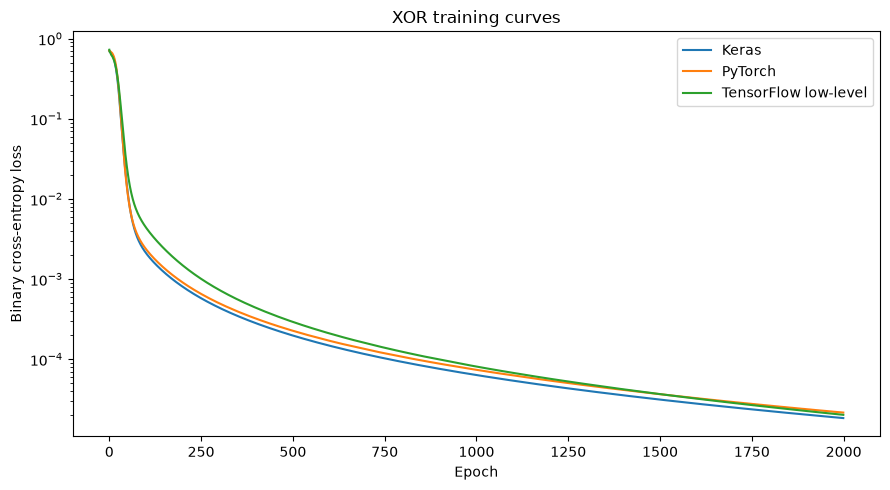

In [6]:
library_comparison = pd.DataFrame({
    "Library": ["Keras", "PyTorch", "TensorFlow low-level"],
    "Final Loss": [
        keras_history.history["loss"][-1],
        pytorch_losses[-1],
        tf_losses[-1],
    ],
    "Accuracy": [
        keras_accuracy,
        pytorch_accuracy,
        tensorflow_accuracy,
    ],
})
display(
    library_comparison.style.format({
        "Final Loss": "{:.6f}",
        "Accuracy": "{:.2%}",
    })
)

plt.figure(figsize=(9, 5))
plt.plot(keras_history.history["loss"], label="Keras")
plt.plot(pytorch_losses, label="PyTorch")
plt.plot(tf_losses, label="TensorFlow low-level")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("XOR training curves")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Decision boundaries

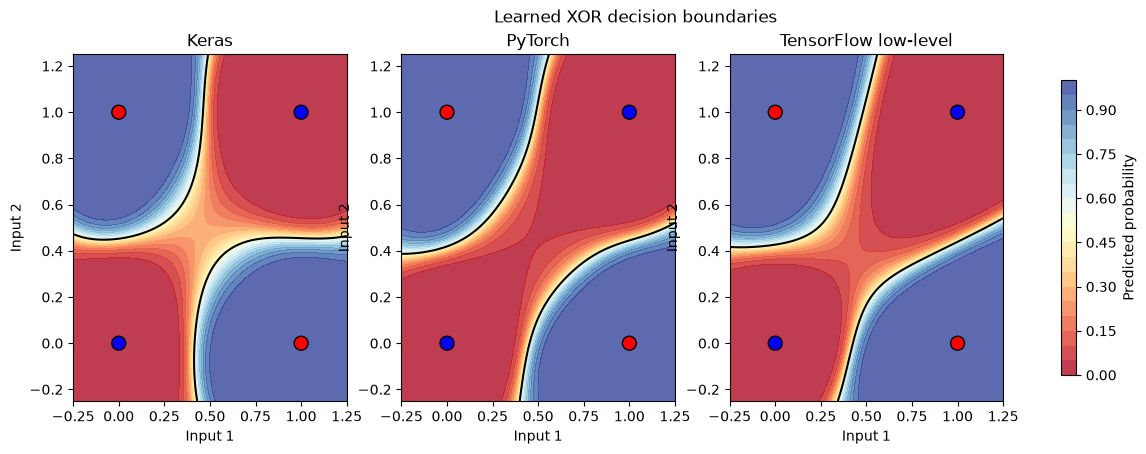

In [7]:
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(-0.25, 1.25, 180),
    np.linspace(-0.25, 1.25, 180),
)
grid = np.column_stack([grid_x1.ravel(), grid_x2.ravel()]).astype(np.float32)

keras_grid = keras_model.predict(grid, verbose=0).reshape(grid_x1.shape)

with torch.no_grad():
    pytorch_grid = (
        pytorch_model(torch.tensor(grid, dtype=torch.float32))
        .numpy()
        .reshape(grid_x1.shape)
    )

tensorflow_grid = (
    tensorflow_forward(tf.constant(grid))
    .numpy()
    .reshape(grid_x1.shape)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for axis, surface, title in zip(
    axes,
    [keras_grid, pytorch_grid, tensorflow_grid],
    ["Keras", "PyTorch", "TensorFlow low-level"],
):
    contour = axis.contourf(
        grid_x1, grid_x2, surface,
        levels=np.linspace(0, 1, 21),
        cmap="RdYlBu",
        alpha=0.8,
    )
    axis.contour(grid_x1, grid_x2, surface, levels=[0.5], colors="black")
    axis.scatter(
        X_np[:, 0], X_np[:, 1],
        c=y_np.reshape(-1),
        cmap="bwr",
        edgecolors="black",
        s=100,
    )
    axis.set_title(title)
    axis.set_xlabel("Input 1")
    axis.set_ylabel("Input 2")
    axis.set_xlim(-0.25, 1.25)
    axis.set_ylim(-0.25, 1.25)

fig.colorbar(contour, ax=axes, label="Predicted probability", shrink=0.85)
fig.suptitle("Learned XOR decision boundaries")
plt.show()

## 8. Hyperparameter experiment

The following PyTorch trials change one main setting at a time. The same seed and full XOR table are used for each run.

,Setting,Neurons,Activation,Learning Rate,Epochs,Final Loss,Accuracy
0,Baseline,4,tanh,0.050,1000,0.000561,100.00%
1,Low learning rate,4,tanh,0.001,1000,0.224785,100.00%
2,High learning rate,4,tanh,0.200,1000,0.000024,100.00%
3,ReLU activation,4,relu,0.050,1000,0.346785,75.00%
4,Sigmoid activation,4,sigmoid,0.050,1000,0.002599,100.00%
5,2 hidden neurons,2,tanh,0.050,1000,0.346784,50.00%
6,8 hidden neurons,8,tanh,0.050,1000,0.000058,100.00%
7,Few epochs,4,tanh,0.050,100,0.019205,100.00%
8,More epochs,4,tanh,0.050,2000,0.000167,100.00%


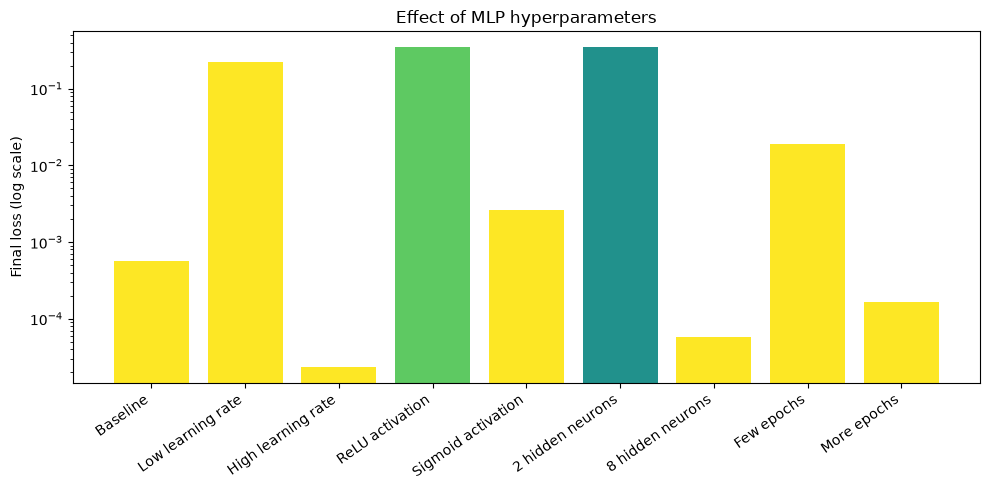

In [8]:
def run_pytorch_experiment(
    neurons=4,
    activation="tanh",
    learning_rate=0.05,
    epochs=1000,
    seed=123,
):
    torch.manual_seed(seed)
    activation_layer = {
        "tanh": nn.Tanh(),
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
    }[activation]

    model = nn.Sequential(
        nn.Linear(2, neurons),
        activation_layer,
        nn.Linear(neurons, 1),
        nn.Sigmoid(),
    )
    loss_function = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    final_loss = None
    for _ in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_torch)
        loss = loss_function(outputs, y_torch)
        loss.backward()
        optimizer.step()
        final_loss = loss.item()

    with torch.no_grad():
        probabilities = model(X_torch).numpy().reshape(-1)
    predictions = (probabilities >= 0.5).astype(int)
    accuracy = np.mean(predictions == y_np.reshape(-1))
    return final_loss, accuracy

experiments = [
    {"Setting": "Baseline", "Neurons": 4, "Activation": "tanh", "Learning Rate": 0.05, "Epochs": 1000},
    {"Setting": "Low learning rate", "Neurons": 4, "Activation": "tanh", "Learning Rate": 0.001, "Epochs": 1000},
    {"Setting": "High learning rate", "Neurons": 4, "Activation": "tanh", "Learning Rate": 0.20, "Epochs": 1000},
    {"Setting": "ReLU activation", "Neurons": 4, "Activation": "relu", "Learning Rate": 0.05, "Epochs": 1000},
    {"Setting": "Sigmoid activation", "Neurons": 4, "Activation": "sigmoid", "Learning Rate": 0.05, "Epochs": 1000},
    {"Setting": "2 hidden neurons", "Neurons": 2, "Activation": "tanh", "Learning Rate": 0.05, "Epochs": 1000},
    {"Setting": "8 hidden neurons", "Neurons": 8, "Activation": "tanh", "Learning Rate": 0.05, "Epochs": 1000},
    {"Setting": "Few epochs", "Neurons": 4, "Activation": "tanh", "Learning Rate": 0.05, "Epochs": 100},
    {"Setting": "More epochs", "Neurons": 4, "Activation": "tanh", "Learning Rate": 0.05, "Epochs": 2000},
]

experiment_rows = []
for experiment in experiments:
    loss, accuracy = run_pytorch_experiment(
        neurons=experiment["Neurons"],
        activation=experiment["Activation"],
        learning_rate=experiment["Learning Rate"],
        epochs=experiment["Epochs"],
    )
    experiment_rows.append({
        **experiment,
        "Final Loss": loss,
        "Accuracy": accuracy,
    })

hyperparameter_results = pd.DataFrame(experiment_rows)
display(
    hyperparameter_results.style.format({
        "Learning Rate": "{:.3f}",
        "Final Loss": "{:.6f}",
        "Accuracy": "{:.2%}",
    })
)

fig, axis = plt.subplots(figsize=(10, 5))
bars = axis.bar(
    hyperparameter_results["Setting"],
    hyperparameter_results["Final Loss"],
    color=plt.cm.viridis(
        hyperparameter_results["Accuracy"].to_numpy()
    ),
)
axis.set_yscale("log")
axis.set_ylabel("Final loss (log scale)")
axis.set_title("Effect of MLP hyperparameters")
axis.tick_params(axis="x", rotation=35)
for label in axis.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

### Hyperparameter observations

- The low learning rate gave a higher final loss, showing slower learning.
- Tanh and sigmoid reached 100%, while this ReLU trial reached 75%.
- The 2-neuron trial reached 50%, while 8 neurons reached 100%.
- More epochs reduced the final loss.

## Conclusion

All three implementations learned the XOR truth table. The hidden layer allowed the models to form a non-linear decision boundary. Learning rate, activation, neurons, and epochs affected the final loss and convergence speed.